In [1]:
import sys
sys.path.append('/home/boris/projects/aimasters/1sem/ML1/utils')


In [310]:
from utils import get_split, train_linear_model, get_df_info_mine, get_df_info, plot_density, correlation_matrix
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from difflib import SequenceMatcher
from rapidfuzz import fuzz
from lightgbm import LGBMRanker
from lightgbm import early_stopping, log_evaluation
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.linear_model import LogisticRegression
import tqdm


In [16]:
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

In [3]:
train_const = pd.read_parquet('train-dset.parquet')
test_const = pd.read_parquet('test-dset-small.parquet')

In [82]:
train_sample = train_const.loc[:1000000]

In [28]:
display(train_sample['query_id'].nunique())

8708

In [9]:
query1 = train_const.loc[train_const['query_id']==train_const['query_id'][10]]

In [48]:
train_sample.loc[:100].to_csv('first100.csv')

In [ ]:
train_sample['matching_ratio'] = train_sample.apply(lambda x:fuzz.ratio(x.query_text, x.item_title), axis=1).to_list()

In [67]:
def extract_english_brand_tokens(text: str) -> list:
    """
    Извлекает токены, состоящие из латинских букв, 
    возможно содержащие внутренние дефисы или апострофы.
    Отбрасывает токены, начинающиеся/заканчивающиеся на спецсимволы.
    """
    if pd.isna(text):
        return []
    # Разрешаем дефис и апостроф ВНУТРИ слова
    tokens = re.findall(r"\b[a-zA-Z]+(?:[-'][a-zA-Z]+)*\b", str(text))
    return [t.lower() for t in tokens if t.isascii()]
    

In [63]:
def extract_words_with_digits(text):
    """
    Извлекает все слова, содержащие хотя бы одну цифру.
    
    Слово определяется как последовательность букв, цифр, дефисов или апострофов,
    но обязательно включающая хотя бы одну цифру.
    
    Args:
        text (str or NaN): входной текст
    
    Returns:
        list[str]: список слов с цифрами (в нижнем регистре)
    """
    if pd.isna(text):
        return []
    
    # Находим все "слова", состоящие из букв, цифр, дефисов и апострофов
    tokens = re.findall(r"\b[a-zA-Z0-9]+(?:[-'][a-zA-Z0-9]+)*\b", str(text))
    
    # Фильтруем только те, что содержат хотя бы одну цифру
    words_with_digits = [token.lower() for token in tokens if re.search(r'\d', token)]
    
    return words_with_digits

In [ ]:
def has_digit_word_match(row):
        query_tokens = set(extract_words_with_digits(row['query_text']))
        title = str(row['item_title']).lower()
        desc = str(row['item_description']).lower()
        for token in query_tokens:
            if token in title or token in desc:
                return 1
        return 0

In [74]:
def has_brand_match(row):
        query_tokens = set(extract_english_brand_tokens(row['query_text']))
        title = str(row['item_title']).lower()
        desc = str(row['item_description']).lower()
        for token in query_tokens:
            if token in title or token in desc:
                return 1
        return 0

In [86]:
train_sample['brand_match'] = train_sample.apply(has_brand_match, axis=1)
train_sample['digit_word_match'] = train_sample.apply(has_digit_word_match, axis=1)

Предупреждение: 3 нечисловых колонок исключены из анализа корреляций.
Расчет матрицы корреляций для 14 признаков...
Матрица корреляций рассчитана.


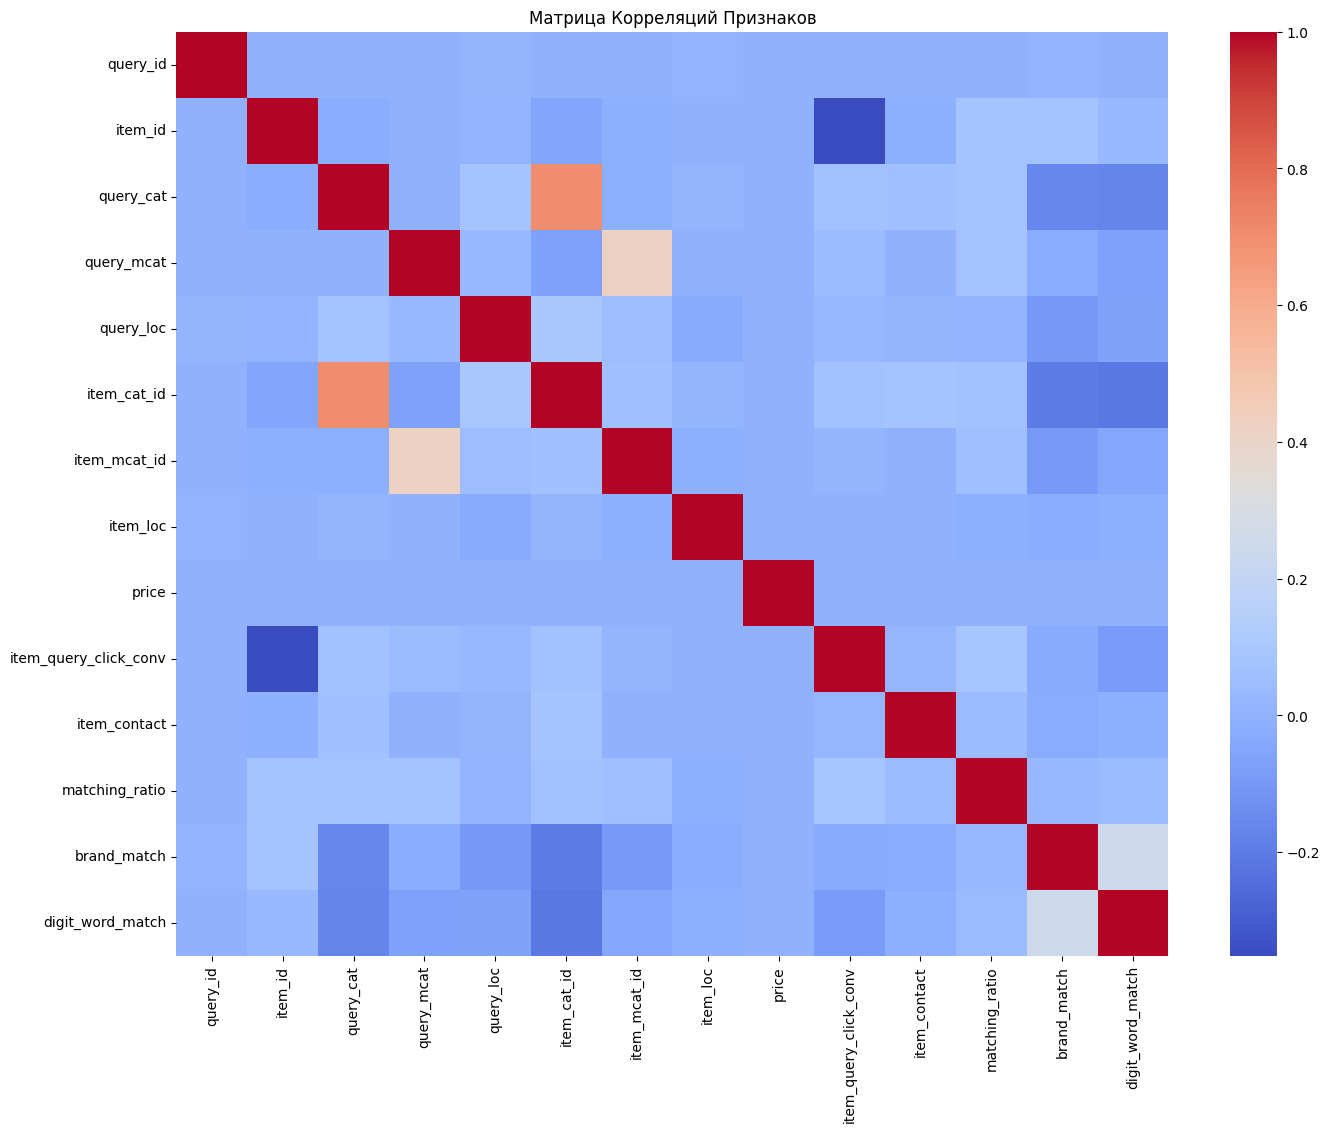


Поиск сильно скоррелированных пар (абсолютное значение > 0.95)...
Сильно скоррелированных пар (> 0.95) не найдено.


In [88]:
correlation_matrix(train_sample)

In [99]:
query_length = train_sample.groupby('query_id', sort=False).size().values
train_length = int(len(query_length)*0.8)
test_length = len(query_length) - train_length
queries_train = query_length[:train_length]
queries_test = query_length[train_length:len(query_length)]

In [101]:
train_sample_train = train_sample[:sum(queries_train)]
train_sample_test = train_sample[sum(queries_train):sum(query_length)]

In [139]:
def build_features(df):
    df = df.copy()
    
    # Заполним пропуски
    print('Imputing...')
    df['item_description'] = df['item_description'].fillna('')
    df['item_title'] = df['item_title'].fillna('')
    df['query_text'] = df['query_text'].fillna('')
    
    # Совпадение категорий и локаций
    print('cat collisions...')
    df['cat_match'] = (df['query_cat'] == df['item_cat_id']).astype(int)
    df['mcat_match'] = (df['query_mcat'] == df['item_mcat_id']).astype(int)
    df['loc_match'] = (df['query_loc'] == df['item_loc']).astype(int)
    
    # Цена
    print('price transfrom...')
    df['price_log'] = np.log1p(df['price'])
    price_stats = df.groupby('query_id')['price'].agg(['mean', 'std']).reset_index()
    price_stats.columns = ['query_id', 'price_mean', 'price_std']
    df = df.merge(price_stats, on='query_id', how='left')
    df['price_std'] = df['price_std'].fillna(0)
    df['price_norm'] = (df['price'] - df['price_mean']) / (df['price_std'] + 1e-6)

    # Совпадение названий брендов и моделей/размеров
    print('brand collisions...')
    df['brand_match'] = df.apply(has_brand_match, axis=1)
    df['digit_word_match'] = df.apply(has_digit_word_match, axis=1)

    # string distance
    print('string distance...')
    df['query_text'] = df['query_text'].fillna('').astype(str)
    df['item_title'] = df['item_title'].fillna('').astype(str)

    df['matching_ratio'] = df.apply(lambda x:fuzz.ratio(x.query_text.lower(), x.item_title.lower()), axis=1).to_list()

    # TF-IDF similarity
    # print('tfidf...')
    # tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=5000)
    # all_text = pd.concat([df['query_text'], df['item_title'], df['item_description']])
    # tfidf.fit(all_text.fillna('').astype(str))
    
    # query_tfidf = tfidf.transform(df['query_text'].fillna('').astype(str))
    # title_tfidf = tfidf.transform(df['item_title'].fillna('').astype(str))
    # desc_tfidf = tfidf.transform(df['item_description'].fillna('').astype(str))
    
    # df['tfidf_title_sim'] = cosine_similarity(query_tfidf, title_tfidf).diagonal()
    # df['tfidf_desc_sim'] = cosine_similarity(query_tfidf, desc_tfidf).diagonal()
    
    return df

In [144]:
test_trasform = build_features(train_sample_test)
train_trasform = build_features(train_sample_train)

Imputing...
cat collisions...
price transfrom...
brand collisions...
string distance...
Imputing...
cat collisions...
price transfrom...
brand collisions...
string distance...


In [ ]:
feature_cols = ['matching_ratio', 'brand_match', 'digit_word_match', 'cat_match',
       'mcat_match', 'loc_match', 'price_norm']
X_train = train_trasform[feature_cols]
X_test = test_trasform[feature_cols]
y_train = np.array(train_trasform.item_contact)
y_test = np.array(test_trasform.item_contact)
display(queries_train.sum())
display(queries_test.sum())
display(y_train.shape)
display(y_test.shape)
# display(test_trasform[feature_cols])

np.int64(801358)

np.int64(198643)

(801358,)

(198643,)

In [317]:
model = LGBMRanker(n_estimators=15000,
                          random_state=42,
                          num_leaves=41,
                          learning_rate=0.2,
                          #max_bin =20,
                          #subsample_for_bin=20000,
                          colsample_bytree=0.7,
                          n_jobs=2)
callbacks = [
    log_evaluation(period=100),  # печатать каждые 100 итераций
    early_stopping(stopping_rounds=1000, verbose=True)
]
model.fit(X_train,
          y_train,
          group=queries_train,
          callbacks=callbacks,
          eval_set=[(X_test, y_test)],
          eval_group=[queries_test],
          eval_at=[10] #Make evaluation for target=1 ranking, I choosed arbitrarily
          )

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 520
[LightGBM] [Info] Number of data points in the train set: 801358, number of used features: 7
Training until validation scores don't improve for 1000 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	valid_0's ndcg@10: 0.81584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's ndcg@10: 0.814901
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,41
,max_depth,-1
,learning_rate,0.2
,n_estimators,15000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [318]:
display(X_train.columns)

Index(['matching_ratio', 'brand_match', 'digit_word_match', 'cat_match',
       'mcat_match', 'loc_match', 'price_norm'],
      dtype='str')

In [170]:
classifier = LogisticRegression(penalty='l2')

In [171]:
classifier.fit(X_train, y_train)

/home/boris/projects/python/avito/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

/home/boris/projects/python/avito/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/boris/projects/python/avito/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


Train: 0.5936022137248717
Test: 0.5863669765954881


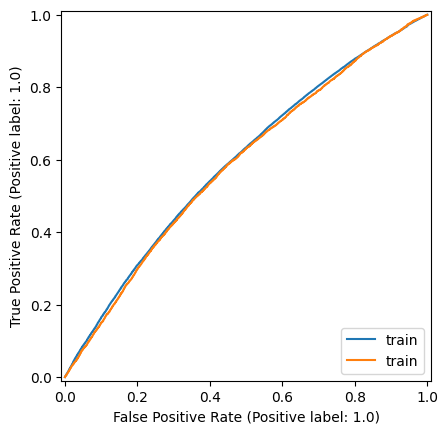

In [176]:
fig, ax = plt.subplots(1,1)
y_pred_tr = classifier.predict_proba(X_train)[:,1]
y_pred_tst = classifier.predict_proba(X_test)[:,1]
train_disp = RocCurveDisplay.from_estimator(classifier, X_train, y_train, ax=ax, label='train')
test_disp = RocCurveDisplay.from_estimator(classifier, X_test, y_test, ax=ax, label='train')
print(f"Train: {roc_auc_score(y_train, y_pred_tr)}")
print(f"Test: {roc_auc_score(y_test, y_pred_tst)}")

array([32, 29,  9, ..., 11, 17,  6], shape=(17414,))

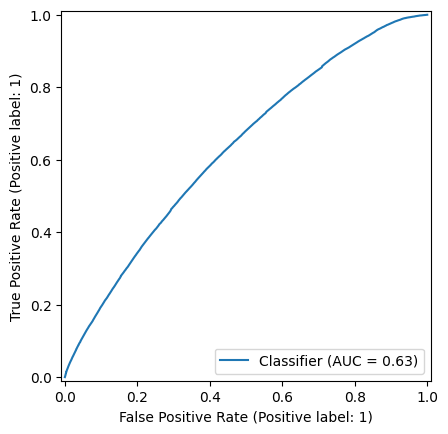

In [162]:
display(queries_test)
# display(model.predict(X_test.loc), y_test[:32])
clf_disp = RocCurveDisplay.from_predictions(y_train, model.predict(X_train))

In [164]:
def calc_dcg_at_k(v: np.ndarray, k: int = 10) -> float:
    w = 0.97 ** np.arange(len(v))
    return (v * w)[:k].sum()


def calc_idcg_at_k(v: np.ndarray, k: int = 10) -> float:
    return calc_dcg_at_k(np.sort(v)[::-1], k)


def calc_ndcg_at_k(v: np.ndarray, k: int = 10) -> float:
    return calc_dcg_at_k(v, k) / calc_idcg_at_k(v, k)

In [207]:
def compute_ndcg_per_query(df: pd.DataFrame, pred_col: str = 'pred', target_col: str = 'item_contact', query_col: str = 'query_id', k: int = 10) -> float:
    """
    Вычисляет средний NDCG@k по всем query_id в DataFrame.
    
    df: DataFrame с колонками [query_id, item_contact, pred]
    pred_col: имя колонки с предсказанными скорами
    target_col: имя колонки с истинной релевантностью (0/1)
    query_col: имя колонки с идентификатором запроса
    k: глубина ранжирования
    """
    ndcg_scores = []

    for qid, group in tqdm.tqdm(df.groupby(query_col)):
        # Сортируем по убыванию предсказаний
        group_sorted = group.sort_values(by=pred_col, ascending=False)
        # Извлекаем истинные релевантности в порядке ранжирования
        rels = group_sorted[target_col].values.astype(float)
        # Вычисляем NDCG@k
        score = calc_ndcg_at_k(rels, k=k)
        ndcg_scores.append(score)

    return np.mean(ndcg_scores)

100%|██████████| 10000/10000 [00:02<00:00, 4217.75it/s]


<Axes: >

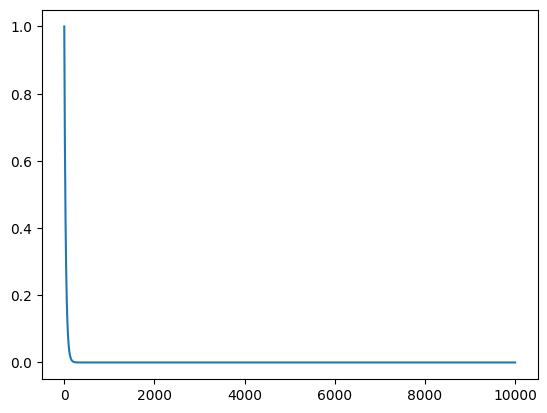

In [191]:
# Предположим, у вас есть test_df с колонками: ['query_id', 'item_contact']
l=10000
scores = np.zeros(l)
for i in tqdm.tqdm(range(l)):
    array = np.zeros(l)
    array[i]=1
    scores[i] = calc_ndcg_at_k(array, k = l)
    # print(f"NDCG@10 (custom decay): {final_score:.5f}")
sns.lineplot(x=range(l), y=scores)

In [320]:
def create_synthetic_dataset(num_of_queries:int = 100):
    group_sizes = np.random.randint(low = 10, high = 50, size = num_of_queries)
    features = np.random.normal(size=(group_sizes.sum(),3))
    result = pd.DataFrame(features, columns=['f1','f2','f3'])
    result['query_id'] = np.repeat(np.arange(1,num_of_queries+1), group_sizes)
    result['target'] = result['f1'] + result['f2'] + result['f3'] > 2.5
    result['target'] = result['target'].astype('Int64')
    return result, group_sizes
synthetic_dataset_train, groups_train = create_synthetic_dataset(10000)
synthetic_dataset_test, groups_test = create_synthetic_dataset(1000)
synthetic_dataset_train

,f1,f2,f3,query_id,target
0,1.188020,-0.846415,-0.075605,1,0
1,0.912298,0.118686,-0.871258,1,0
2,0.559470,-0.169576,0.234511,1,0
3,0.099907,-0.830575,-0.256433,1,0
4,-0.407125,0.117230,1.195559,1,0
...,...,...,...,...,...
295138,0.147556,0.435553,-1.362039,10000,0
295139,0.709650,0.146536,-0.109489,10000,0
295140,1.039795,-0.203092,-0.574518,10000,0
295141,-0.668647,-1.777689,-0.443591,10000,0


In [321]:
X_train_synt = synthetic_dataset_train[['f1', 'f2', 'f3']]
X_test_synt = synthetic_dataset_test[['f1', 'f2', 'f3']]
y_train_synt = np.array(synthetic_dataset_train['target'])
y_test_synt = np.array(synthetic_dataset_test['target'])
display(X_train_synt.shape)
display(y_train_synt.shape)
display(X_test_synt.shape)
display(y_test_synt.shape)
model1 = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
)
model1.fit(X_train_synt,
          y_train_synt,
          group=groups_train,
          eval_set=[(X_test_synt, y_test_synt)],
          eval_group=[groups_test],
          eval_at=[1] #Make evaluation for target=1 ranking, I choosed arbitrarily
          )

(295143, 3)

(295143,)

(29842, 3)

(29842,)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012700 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 295143, number of used features: 3


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [322]:
model_return = LGBMRanker(n_estimators=15000,
                          random_state=42,
                          num_leaves=41,
                          learning_rate=0.05,
                          #max_bin =20,
                          #subsample_for_bin=20000,
                          colsample_bytree=0.7,
                          n_jobs=2)
callbacks = [
    log_evaluation(period=100),  # печатать каждые 100 итераций
    early_stopping(stopping_rounds=1000, verbose=True)
]
model_return.fit(X_train_synt,
            y_train_synt,
             group = groups_train,
             callbacks=callbacks,
             eval_set=[(X_test_synt, y_test_synt)],
             eval_group=[groups_test],
             eval_at=[1] #Make evaluation for target=1 ranking, I choosed arbitrarily
                )

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 295143, number of used features: 3
Training until validation scores don't improve for 1000 rounds
[100]	valid_0's ndcg@1: 0.991
[200]	valid_0's ndcg@1: 0.995
[300]	valid_0's ndcg@1: 0.996
[400]	valid_0's ndcg@1: 0.997
[500]	valid_0's ndcg@1: 0.996
[600]	valid_0's ndcg@1: 0.996
[700]	valid_0's ndcg@1: 0.996
[800]	valid_0's ndcg@1: 0.995
[900]	valid_0's ndcg@1: 0.995
[1000]	valid_0's ndcg@1: 0.995
[1100]	valid_0's ndcg@1: 0.996
[1200]	valid_0's ndcg@1: 0.996
Early stopping, best iteration is:
[234]	valid_0's ndcg@1: 0.998


,boosting_type,'gbdt'
,num_leaves,41
,max_depth,-1
,learning_rate,0.05
,n_estimators,15000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [198]:
train_sample_test['pred'] = model.predict(X_test)

In [274]:
display(train_sample_test[['query_id','item_contact', 'pred']])
df_sorted = train_sample_test[['query_id','item_contact', 'pred']].sort_values(by=['query_id', 'pred'], ascending=[True, False])
display(df_sorted)


,query_id,item_contact,pred
801358,339432,0.0,0.076471
801359,339432,0.0,-0.088264
801360,339432,1.0,-0.009346
801361,339432,0.0,-0.025430
801362,339432,0.0,-0.009415
...,...,...,...
999996,424883,0.0,0.054344
999997,424883,1.0,-0.030435
999998,424883,0.0,0.043973
999999,424883,0.0,0.090817


,query_id,item_contact,pred
801358,339432,0.0,0.076471
801365,339432,0.0,0.039480
801374,339432,0.0,0.033403
801372,339432,0.0,0.024876
801381,339432,0.0,0.008513
...,...,...,...
999995,424883,0.0,0.060216
999996,424883,0.0,0.054344
999998,424883,0.0,0.043973
1000000,424883,1.0,0.032258


In [272]:
scores = np.array(df_sorted.groupby('query_id').apply(lambda x: calc_ndcg_at_k(x['item_contact'])))
np.bool(1-np.isnan(scores))
scores = scores[np.bool(1-np.isnan(scores))]

/tmp/ipykernel_2588264/3326853880.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return calc_dcg_at_k(v, k) / calc_idcg_at_k(v, k)


In [273]:
scores.mean()

np.float64(0.729355182622496)

In [252]:
l = 1000000
rand_score = 0
for i in tqdm.tqdm(range(l)):
    idx = np.random.randint(0,10)
    arr = np.zeros(10)
    arr[idx] = 1
    rand_score += calc_ndcg_at_k(arr)
display(rand_score/l)

100%|██████████| 1000000/1000000 [00:10<00:00, 96963.00it/s]


np.float64(0.8753327955677614)

90


<Axes: >

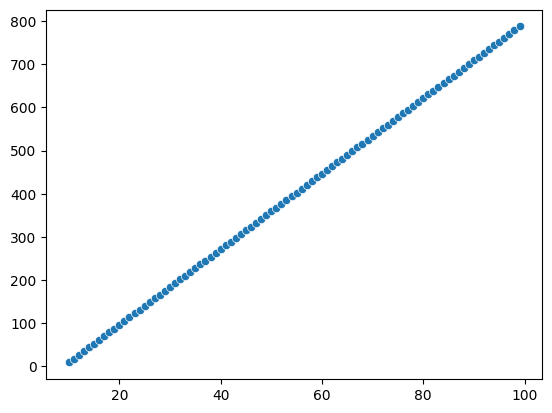

In [270]:
rand_score = 0
print(len(range(10,100)))
rand_scores = np.zeros(90)
for l in range(10,100):
    for i in range(l):
        arr = np.zeros(l)
        arr[i]=1
        rand_score += calc_ndcg_at_k(arr)
    rand_scores[l-10] = rand_score
sns.scatterplot(x=range(10,100), y=rand_scores)

In [209]:
compute_ndcg_per_query(train_sample_test[['query_id','item_contact', 'pred']])

  0%|          | 0/17414 [00:00<?, ?it/s]/tmp/ipykernel_2588264/3326853880.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return calc_dcg_at_k(v, k) / calc_idcg_at_k(v, k)
100%|██████████| 17414/17414 [00:03<00:00, 4849.37it/s]


np.float64(nan)